# 1st Assignment of ML

* Data Cleaning

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.get_dataset_names()
table = sns.load_dataset('titanic')
df = table.copy()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [3]:
df.describe(include='object')
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Filling the missing values

df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['deck'].value_counts()
df['deck'] = df['deck'].fillna(df['deck'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


* EDA - Exploratory Data Analysis

<Axes: >

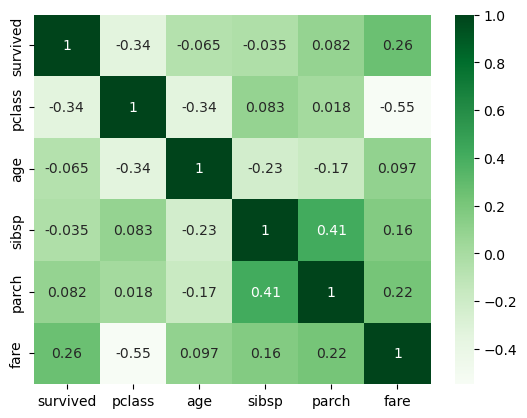

In [6]:
cols = ['survived','pclass','age','sibsp','parch','fare']
sns.heatmap(df[cols].corr(),annot = True,cmap = "Greens")

<Axes: xlabel='survived', ylabel='fare'>

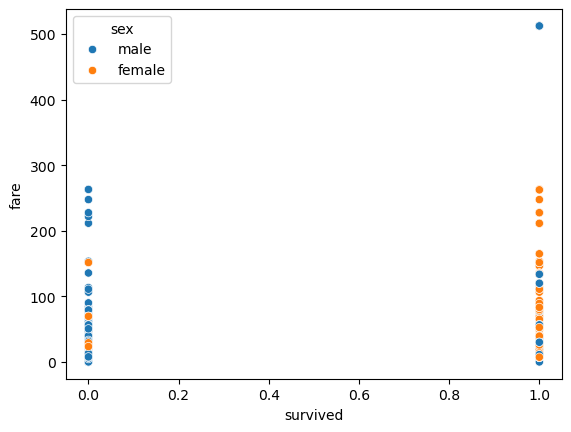

In [7]:
sns.scatterplot(data=df, 
    x="survived", 
    y="fare", 
    hue="sex")

<Axes: xlabel='survived', ylabel='Count'>

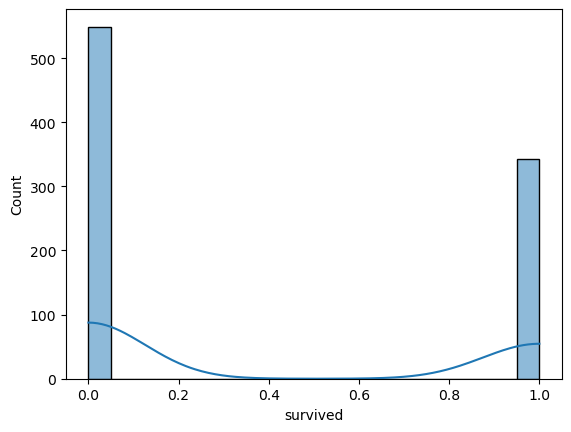

In [8]:
sns.histplot(df['survived'], kde = True, bins= 20)

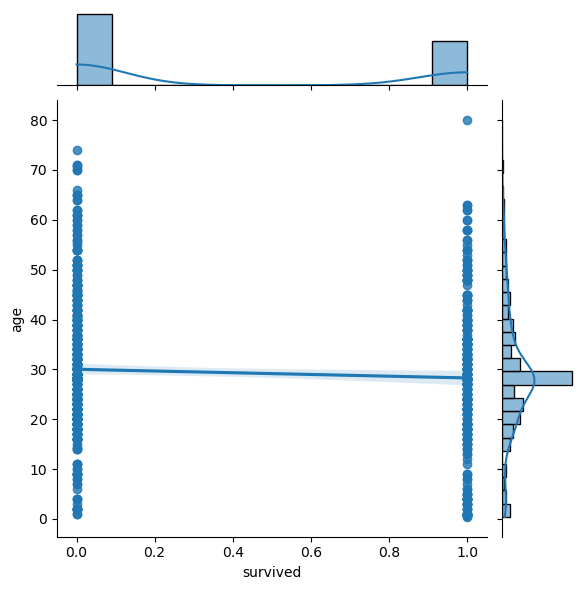

In [9]:
sns.jointplot(x = 'survived', y = 'age', data = df,kind='reg')
plt.show()

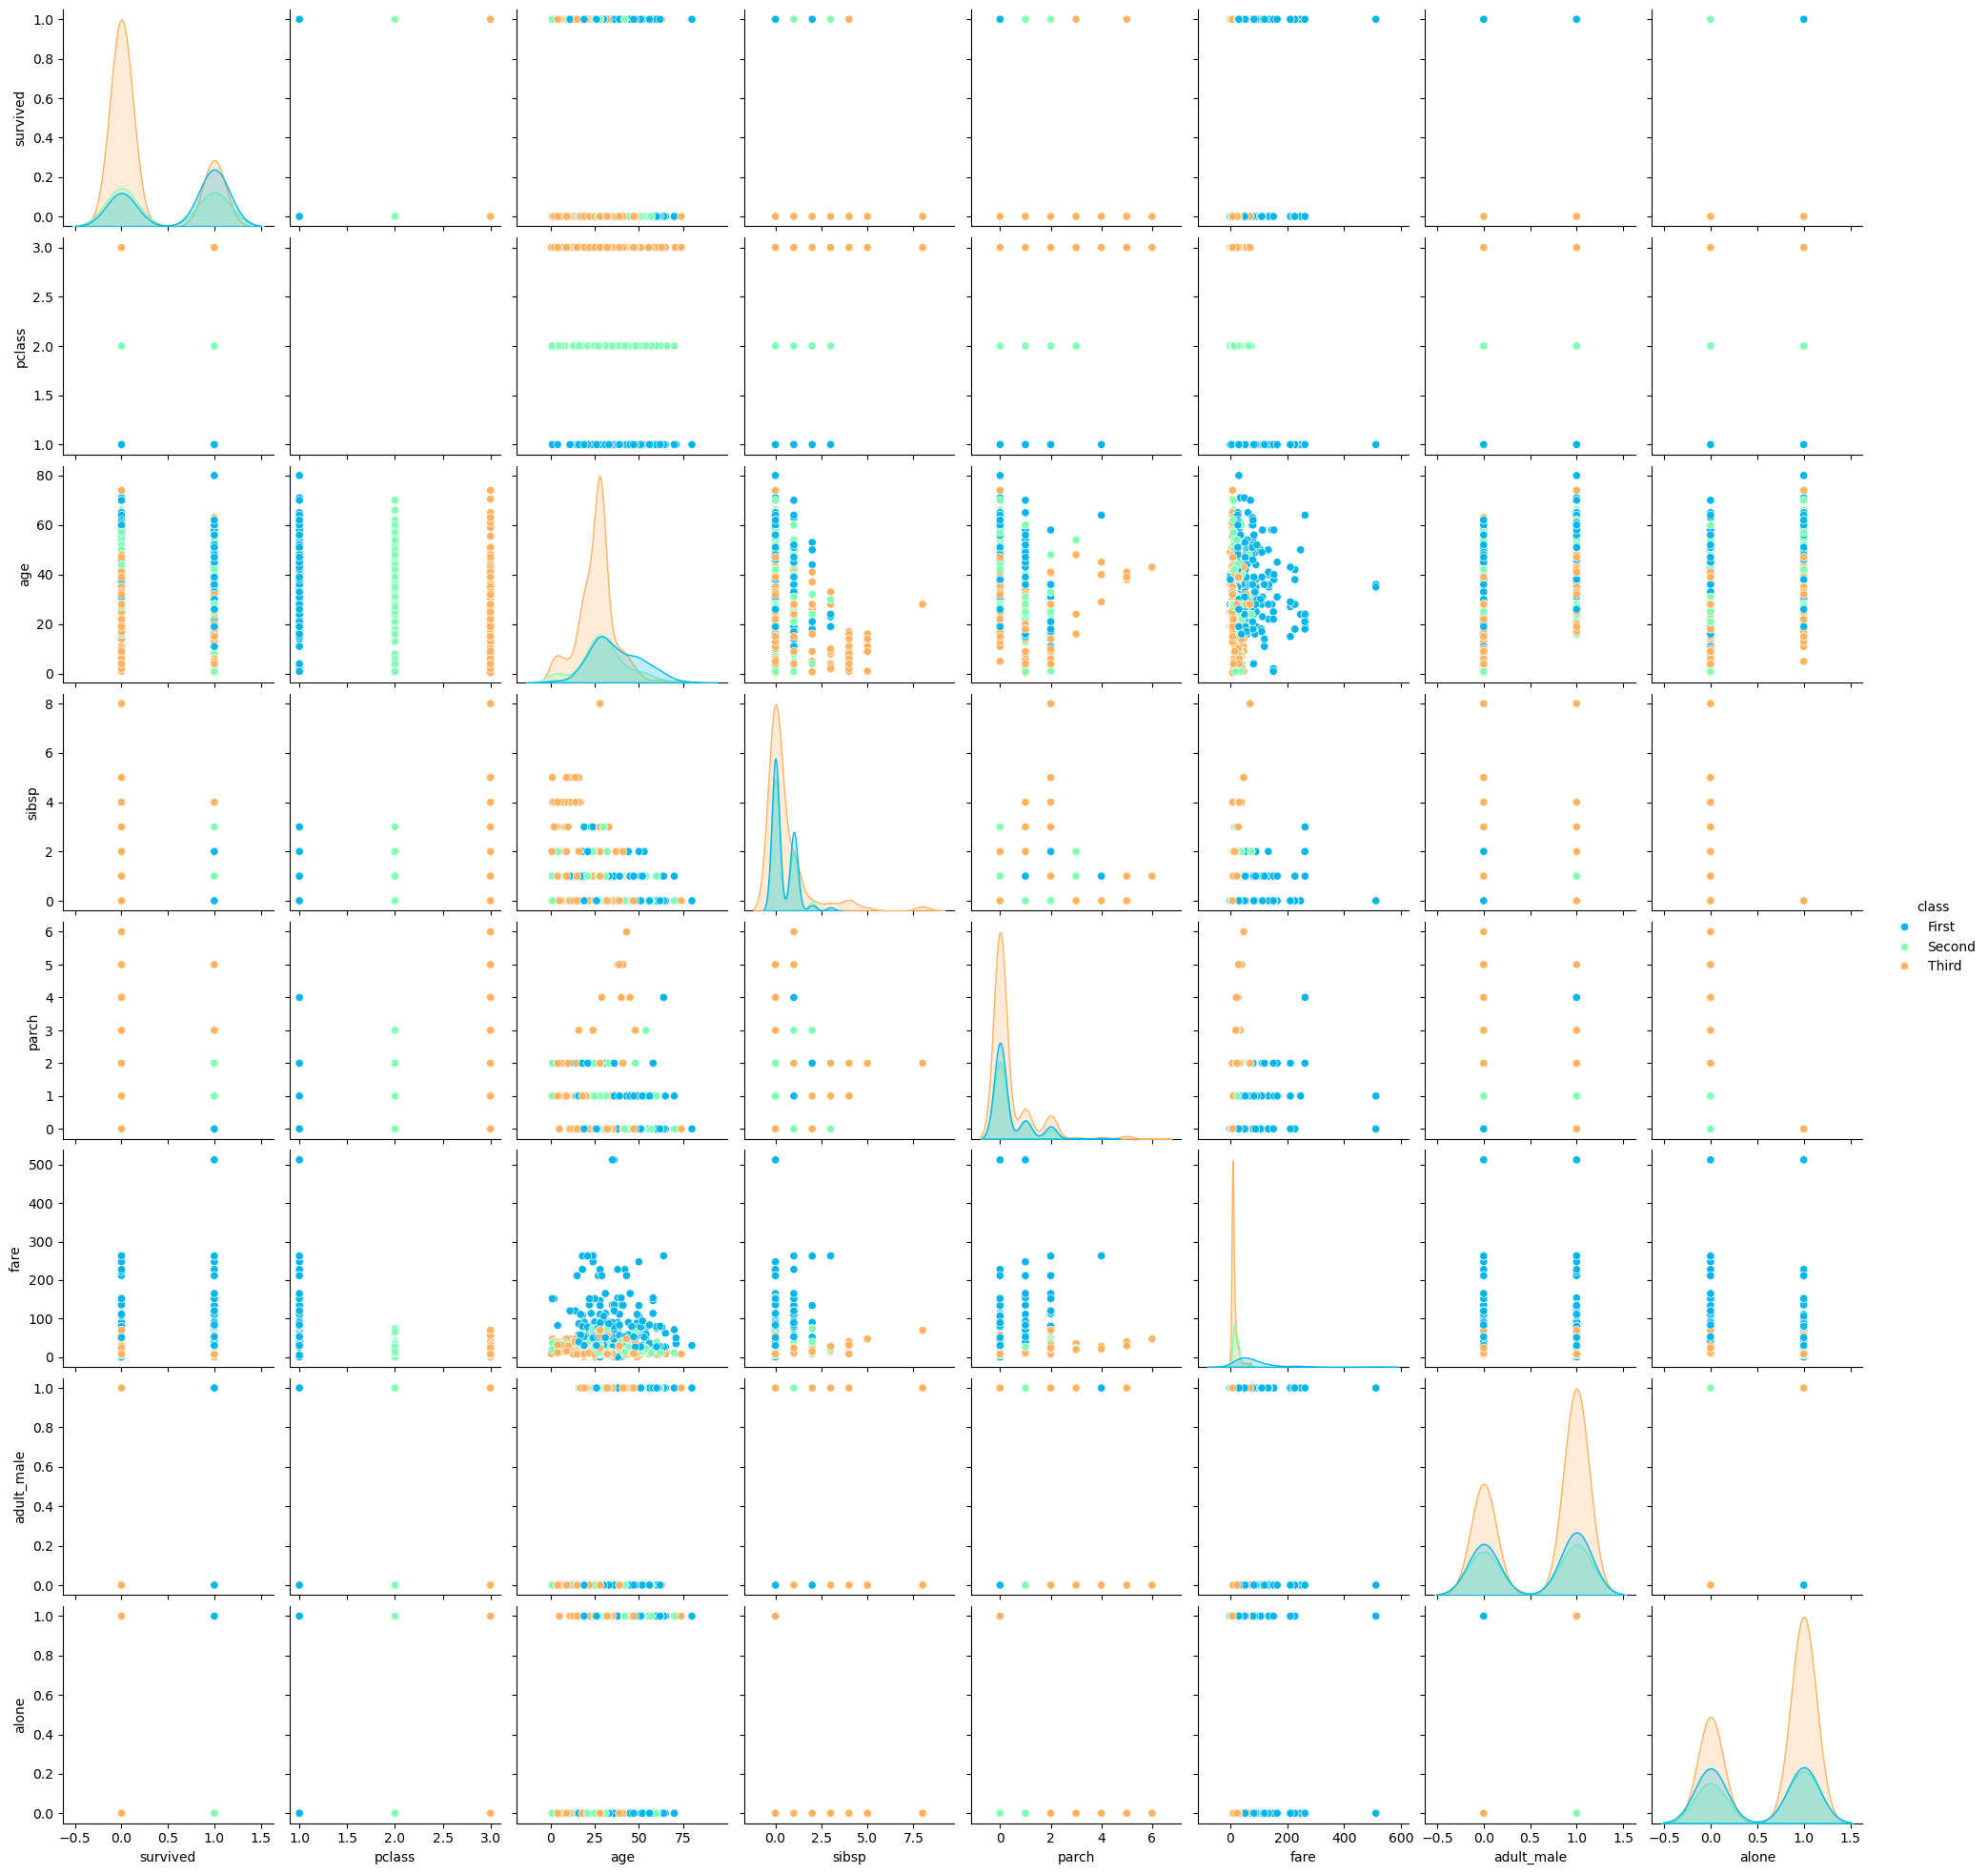

In [10]:
sns.pairplot(df,hue='class',palette='rainbow') 

# Remarks on Analysis :-

* With the help of above heat map, we can upto some extent that whoever has paid high fare has more survival rate then others passangers. Means, here is a bit positive ralationship between FARE and SURVIVED variables.
* In comparision of male fremale survived more.
* Deceased people near the twice to survived people.

* Fature Engenieering

In [11]:
df['alive'] = df['alive'].map({'no':0,'yes':1})

In [12]:
df['alone'] = df['alone'].astype(int)

In [13]:
df['adult_male'] = df['adult_male'].astype(int)

In [14]:
df = pd.get_dummies(df,columns=['embarked','class','who','deck','embark_town'],dtype=int)

In [36]:
x = df[['class_First','class_Second','class_Third','parch','sibsp','age']]
y = df['fare']

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ['pclass']

df[cols] = scaler.fit_transform(x[cols])

"\ncols = ['pclass']\n\ndf[cols] = scaler.fit_transform(x[cols])"

In [17]:
x_scale.shape

(891, 6)

# 2nd Assignment of ML

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [45]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
pred = model.predict(X_test)
pred

array([ 22.08607563,  14.45586568,   8.12861705,  30.46252668,
        13.98730419,  82.35206058,   6.50648586,  18.22386015,
         8.93968264, 105.64642742,  84.76371894,   3.26222347,
        31.37025313,   6.10095306,  13.44203369,  95.31722559,
        83.74988694,   6.50648586,  15.26693128,  78.0939662 ,
         7.31755145,  80.72992938,  12.9734722 ,   8.12861705,
         6.50648586,  45.95754934,  79.51333099,  14.45586568,
        47.17414773,   5.89818666,   8.33138345,   7.72308425,
        81.94652778,   6.50648586,   8.53414985,  11.35134101,
        81.94652778,   6.50648586,  81.54099498,   6.50648586,
        25.76770717,  10.94580821,   6.50648586,   6.50648586,
        13.9969581 ,  46.39427447,   8.33138345,   7.52031785,
         7.31755145,  97.73853786,  31.39179156,  92.65972398,
        52.46538192, 111.91064736,  -0.9958709 , 105.84919382,
        14.25309928,  88.42316803,  13.64480009,   8.33138345,
         7.92585065,  29.04316189,  19.70625363,  81.94

In [49]:
from sklearn import metrics

print('MAE : ',metrics.mean_absolute_error(y_test,pred))
print('MAE : ',metrics.mean_squared_error(y_test,pred))
print('MAE : ',np.sqrt(metrics.mean_squared_error(y_test,pred)))

MAE :  16.491114265835197
MAE :  1053.79287922756
MAE :  32.46217613203957


# Logistic Regression

<Axes: >

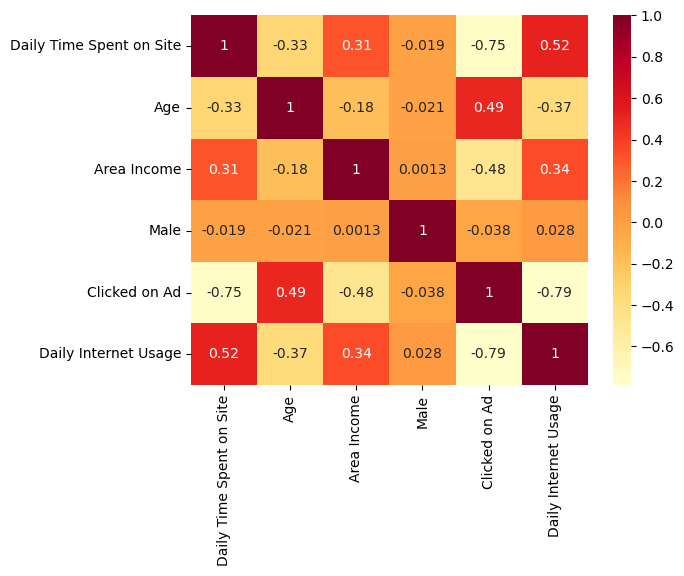

In [73]:
add = pd.read_csv(r"C:\Users\SAHU\OneDrive\Desktop\Data Analytic\ML\Session 8\advertising.csv")
col = ['Daily Time Spent on Site','Age','Area Income','Male','Clicked on Ad','Daily Internet Usage']
sns.heatmap(add[col].corr(),annot=True,cmap = 'tab10')

In [76]:
features = ['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

add[features] = scaler.fit_transform(add[features])
add

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,0.249267,-0.114905,0.509691,1.734030,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,0.961132,-0.570425,1.002530,0.313805,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,0.282083,-1.139826,0.356949,1.287589,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,0.577432,-0.798185,-0.014456,1.501580,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,0.212664,-0.114905,1.408868,1.038731,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0
...,...,...,...,...,...,...,...,...,...,...
995,0.502963,-0.684305,1.222006,0.651314,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1
996,-0.864601,1.023896,0.953329,-1.038735,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1
997,-0.843775,1.707176,-0.938570,-1.358924,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1
998,-0.596389,-1.936986,-0.975484,0.181172,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0


In [77]:
x = add[['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage']]
y = add['Clicked on Ad']

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [79]:
Log_model = LogisticRegression()
Log_model.fit(X_train,y_train)

y_pred = Log_model.predict(X_test)

In [80]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,confusion_matrix

print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.95
[[ 86   3]
 [  7 104]]
0.9719626168224299
0.9369369369369369
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        89
           1       0.97      0.94      0.95       111

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



# Descision Tree Classifier

In [4]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
features = ['sepal_length','sepal_width','petal_length','petal_width']

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

iris[features] = scaler.fit_transform(iris[features])
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.900681,1.019004,-1.340227,-1.315444,setosa
1,-1.143017,-0.131979,-1.340227,-1.315444,setosa
2,-1.385353,0.328414,-1.397064,-1.315444,setosa
3,-1.506521,0.098217,-1.283389,-1.315444,setosa
4,-1.021849,1.249201,-1.340227,-1.315444,setosa
...,...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832,virginica
146,0.553333,-1.282963,0.705921,0.922303,virginica
147,0.795669,-0.131979,0.819596,1.053935,virginica
148,0.432165,0.788808,0.933271,1.448832,virginica


In [7]:
x = iris.drop('species',axis = 1)
y = iris['species']

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
model_DT= DecisionTreeClassifier()

X_train, X_test, y_train, y_test = train_test_split(  x, y, test_size=0.20, random_state=42)

In [101]:
model_DT.fit(X_train,y_train)

prediction = model_DT.predict(X_test)
prediction

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

In [100]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,confusion_matrix

classification_report(y_test,prediction)
accuracy_score(y_test,prediction)
confusion_matrix(y_test,prediction)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

# Random Forest Classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
Model_forest = RandomForestClassifier(n_estimators = 100, random_state = 42)

X_train, X_test, y_train, y_test = train_test_split(  x, y, test_size=0.20, random_state=42)

In [24]:
Model_forest.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
prediction = Model_forest.predict(X_test)

In [26]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,confusion_matrix

classification_report(y_test,prediction)
accuracy_score(y_test,prediction)
confusion_matrix(y_test,prediction)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

# ML model comparision and insights :-

* it is not about the best model for ML, i genueinly think that it is about the need of ours according to data
* like if we are working on a data whose targeted value is in continous than we should opt or go for "Linear Regression Model of ML"
* in the same manner if we are working on a data whose targeted value is in binary classes than we should opt or go for "Logistic Regression Model of ML"
* in the same manner if we are working on a data whose targeted value is in multiple classes than we should opt or go for "Decision Tree Classfier Model of ML"
* and in place of using either "Logistic Regression" or "Decision Tree Classfier" we can go for "Random Forest Model" because Random Forest Algorithm is the most effective in comparision to both because it reduces the probability of mistakes and with the help of ensemble training its takes the majority preditive value, which is most accurate.